In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [3]:
%load_ext autoreload
%autoreload 2

from slrp_ev_data.read_old_data import read_old_data

# Compare old and new data

### Read old data

In [13]:
df_old = read_old_data()
df_old

,date,power,workday
0,2022-01-01 00:00:00,0.0,0
1,2022-01-01 00:15:00,0.0,0
2,2022-01-01 00:30:00,0.0,0
3,2022-01-01 00:45:00,0.0,0
4,2022-01-01 01:00:00,0.0,0
...,...,...,...
77947,2024-03-22 22:45:00,-0.0,1
77948,2024-03-22 23:00:00,-0.0,1
77949,2024-03-22 23:15:00,-0.0,1
77950,2024-03-22 23:30:00,-0.0,1


### Read new data

In [4]:
df_new = pd.read_csv("power_df_2008-2406_v240828.csv", index_col=0)
df_new["recordTimestamp"] = pd.to_datetime(
    df_new["recordTimestamp"], utc=True
).dt.tz_convert("America/Los_Angeles")

In [5]:
df_new

,recordTimestamp,siteId,activeStationIds,totalPower,numberOfActiveSessions,fractionOfRegularSessions,averageRegularPricePerHour,averageScheduledPricePerHour,power1,power2,...,dcosId6,dcosId7,dcosId8,isArtificialData,dayNumber,isWeekend,weekNumber,isHoliday,sch_centsPerHr,reg_centsPerHr
0,2020-08-18 18:30:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
1,2020-08-18 18:35:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
2,2020-08-18 18:40:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
3,2020-08-18 18:45:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
4,2020-08-18 18:50:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400991,2024-06-11 02:25:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,24,False,NaN,NaN
400992,2024-06-11 02:30:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,24,False,NaN,NaN
400993,2024-06-11 02:35:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,24,False,NaN,NaN
400994,2024-06-11 02:40:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,True,1,False,24,False,NaN,NaN


### Visualization

In [73]:
start_date = pd.Timestamp("2023-09-25", tz="America/Los_Angeles")
end_date = pd.Timestamp("2023-09-30", tz="America/Los_Angeles")

number_of_time_ticks = 12

Using x-axis frequency of 12 hours in order to display around 12 ticks.


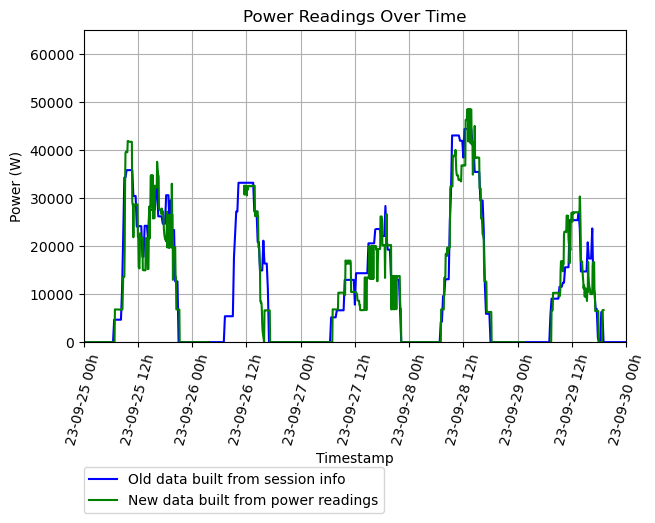

In [74]:
# create the subframe
sub_power_df_old = df_old.query(
    f"recordTimestamp >= '{start_date}' and recordTimestamp <= '{end_date}'"
).copy()
sub_power_df_new = df_new.query(
    f"recordTimestamp >= '{start_date}' and recordTimestamp <= '{end_date}'"
).copy()

# Plot the graph

fig, ax1 = plt.subplots(figsize=(7, 4))
# ax2 = ax1.twinx()
ax1.plot(
    sub_power_df_old["recordTimestamp"],
    sub_power_df_old["totalPower"],
    color="blue",
    label="Old data built from session info",
)
ax1.plot(
    sub_power_df_new["recordTimestamp"],
    sub_power_df_new["totalPower"],
    color="green",
    label="New data built from power readings",
)
ax1.set_ylabel("Power (W)")
ax1.set_ylim(0, 65000)
# # add background color for weekends and public holidays
# ax1.bar(
#     sub_power_df_old["recordTimestamp"],
#     70000 * (sub_power_df_old["isWeekend"] + sub_power_df_old["isHoliday"]),
#     width=pd.Timedelta("5Min"),
#     align="edge",
#     color="lightgrey",
#     alpha=0.5,
#     label="Weekend or Holiday",
# )
# # add background color for missing data
# ax1.bar(
#     sub_power_df_old["recordTimestamp"],
#     70000 * sub_power_df_old["isArtificialData"],
#     width=pd.Timedelta("5Min"),
#     align="edge",
#     color="red",
#     alpha=0.3,
#     label="Missing Data",
# )

# Customize the plot

plt.title("Power Readings Over Time")


# set the time ticks
desired_frequencies = [2, 4, 6, 12, 24, 48, 96, 168, 336, 720, 1440]
x_axis_freq = int(
    (end_date - start_date).total_seconds() / 3600 // number_of_time_ticks
)
# Select the desired frequency that is closest to but not greater than the initial frequency
x_axis_freq = max([freq for freq in desired_frequencies if freq <= x_axis_freq * 1.3])
print(
    f"Using x-axis frequency of {x_axis_freq} hours in order to display around {number_of_time_ticks} ticks."
)
x_axis_freq = f"{x_axis_freq}h"
ax1.set_xlim(start_date, end_date)

ax1.set_xticks(
    pd.date_range(start_date, end_date, freq=x_axis_freq, tz="America/Los_Angeles")
)

ax1.set_xticklabels(
    pd.date_range(
        start_date, end_date, freq=x_axis_freq, tz="America/Los_Angeles"
    ).strftime("%y-%m-%d %Hh"),
    rotation=75,
)
ax1.set_xlabel("Timestamp")

ax1.legend(bbox_to_anchor=(0, -0.4), loc="upper left", borderaxespad=0)
plt.grid(True)
fig.subplots_adjust(bottom=0.1)

# Show the plot

plt.show()

# Data Analysis

## Fourrier analysis for best time frequencies

Fourrier analysis can be used to identify the frequencies of the data, i.e. the most important time features.
See reference [here](https://www.tensorflow.org/tutorials/structured_data/time_series#time)

In [4]:
import tensorflow as tf
import numpy as np

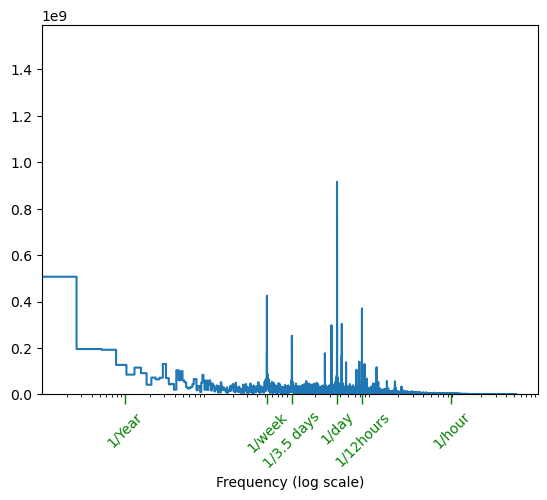

In [22]:
fft = tf.signal.rfft(df_new["totalPower"].fillna(0))
f_per_dataset = np.arange(0, len(fft))

n_samples_5min = len(df_new["totalPower"])
intervals_5min_per_hour = 60 // 5
hours_per_year = 24 * 365.2524
years_per_dataset = n_samples_5min / (hours_per_year * intervals_5min_per_hour)

f_per_year = f_per_dataset / years_per_dataset
fig, ax = plt.subplots()
ax.step(f_per_year, np.abs(fft))
ax.set_xscale("log")
ax.set_ylim([0, max(plt.ylim())])
ax.set_xlim([0.1, max(plt.xlim())])
ax.set_xticks(
    [1, 365.2524 / 7, 365.2524 / 3.5, 365.2524, 365.2524 * 2, hours_per_year],
    labels=["1/Year", "1/week", "1/3.5 days", "1/day", "1/12hours", "1/hour"],
    rotation=45,
)
ax.tick_params(axis="x", colors="green", width=1, length=7)
_ = ax.set_xlabel("Frequency (log scale)")
plt.show()

As shown on the figure above, the most important frequencies are the week and the day (2 highest peaks)

## Distribution of monthly peak power

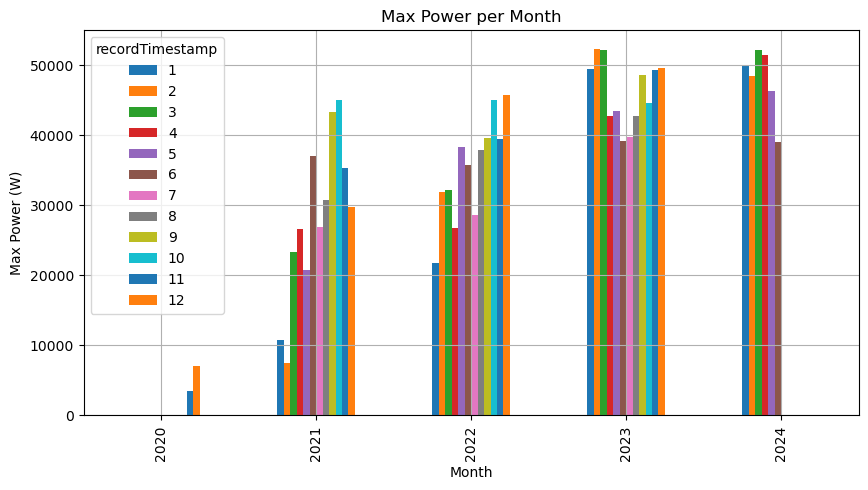

In [5]:
# show max power for each month for each year
monthly_max_power = df_new.groupby(
    [df_new["recordTimestamp"].dt.year, df_new["recordTimestamp"].dt.month]
)["totalPower"].max()

# plot distribution of max monthly power, with a different color for each year
fig, ax = plt.subplots(figsize=(10, 5))
monthly_max_power.unstack().plot(kind="bar", ax=ax)
ax.set_ylabel("Max Power (W)")
ax.set_xlabel("Month")
ax.set_title("Max Power per Month")
plt.grid(True)
plt.show()

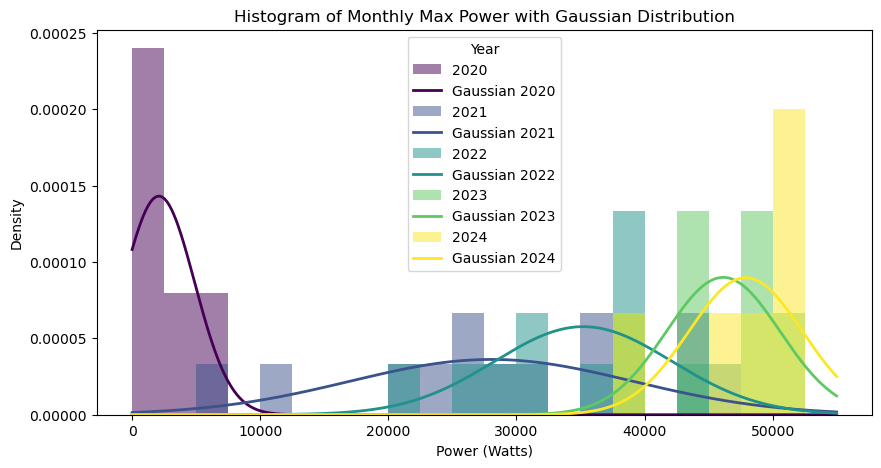

In [8]:
# show max power for each month for each year
monthly_max_power = df_new.groupby(
    [df_new["recordTimestamp"].dt.year, df_new["recordTimestamp"].dt.month]
)["totalPower"].max()


fig, ax = plt.subplots(figsize=(10, 5))

# Define the bin edges
bin_edges = np.arange(0, 55000, 2500)

monthly_max_power = monthly_max_power.unstack()
x = np.linspace(0, 55000, 1000)  # Define the x range for the PDF

colors = plt.cm.viridis(
    np.linspace(0, 1, len(monthly_max_power.index))
)  # Generate a color for each year

for color, year in zip(colors, monthly_max_power.index):
    data = monthly_max_power.loc[year].dropna()

    ax.hist(
        monthly_max_power.loc[year],
        bins=bin_edges,  # Use the defined bin edges
        color=color,
        alpha=0.5,
        label=year,
        density=True,  # Normalize the histogram
    )

    # Fit a normal distribution to the data
    mu, std = norm.fit(data)

    # Plot the PDF
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, linewidth=2, color=color, label=f"Gaussian {year}")

ax.set_xlabel("Power (Watts)")
ax.set_ylabel("Density")
ax.legend(title="Year")
plt.title("Histogram of Monthly Max Power with Gaussian Distribution")
plt.show()

# Tests

In [5]:
x_dim = 5
lookahead = 8

In [20]:
df_test = pd.concat(
    [
        df_old,
        pd.DataFrame(
            {
                f"past_value_{i}": df_old["power"].shift(i) for i in range(x_dim)
            }  # includes the current value
        ),
        pd.DataFrame(
            {
                f"future_value_{j}": df_old["power"].shift(-j)
                for j in range(1, lookahead + 1)
            }
        ),
    ],
    axis=1,
)
df_test["hour_window"] = (
    (df_test["date"].dt.hour + df_test["date"].dt.minute / 60) // 4 * 4
)
df_test

,date,power,workday,past_value_0,past_value_1,past_value_2,past_value_3,past_value_4,future_value_1,future_value_2,future_value_3,future_value_4,future_value_5,future_value_6,future_value_7,future_value_8,hour_window
0,2022-01-01 00:00:00,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-01-01 00:15:00,0.0,0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-01-01 00:30:00,0.0,0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-01-01 00:45:00,0.0,0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-01-01 01:00:00,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77947,2024-03-22 22:45:00,-0.0,1,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,NaN,NaN,NaN,NaN,20.0
77948,2024-03-22 23:00:00,-0.0,1,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,NaN,NaN,NaN,NaN,NaN,20.0
77949,2024-03-22 23:15:00,-0.0,1,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,NaN,NaN,NaN,NaN,NaN,NaN,20.0
77950,2024-03-22 23:30:00,-0.0,1,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0


In [29]:
def extract_x(row):
    return pd.DataFrame.from_dict(
        {
            "power": [row[f"past_value_{i}"] for i in range(x_dim)],
            "workday": row["workday"],
            "time": row["hour_window"],
        },
        orient="tight",
    )


df_test[:100].apply(extract_x, axis=1).iloc[0]
df

KeyError: 'data'